In [2]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

# Configuración de gráficos
plt.style.use('seaborn-v0_8')
pd.set_option('display.float_format', '{:.2f}'.format)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [6]:
# Descargar precio del Brent
brent = yf.download("BZ=F", start="2010-01-01", end="2026-12-31")

# Quedarnos solo con el precio de cierre
brent = brent[["Close"]].copy()
brent.columns = ["precio_brent"]

# Ver los primeros registros
print(f"Datos descargados: {len(brent)} observaciones")
print(f"Período: {brent.index[0].date()} al {brent.index[-1].date()}")
brent.head()

[*********************100%***********************]  1 of 1 completed

Datos descargados: 4053 observaciones
Período: 2010-01-04 al 2026-03-30


,precio_brent
Date,
2010-01-04,80.12
2010-01-05,80.59
2010-01-06,81.89
2010-01-07,81.51
2010-01-08,81.37


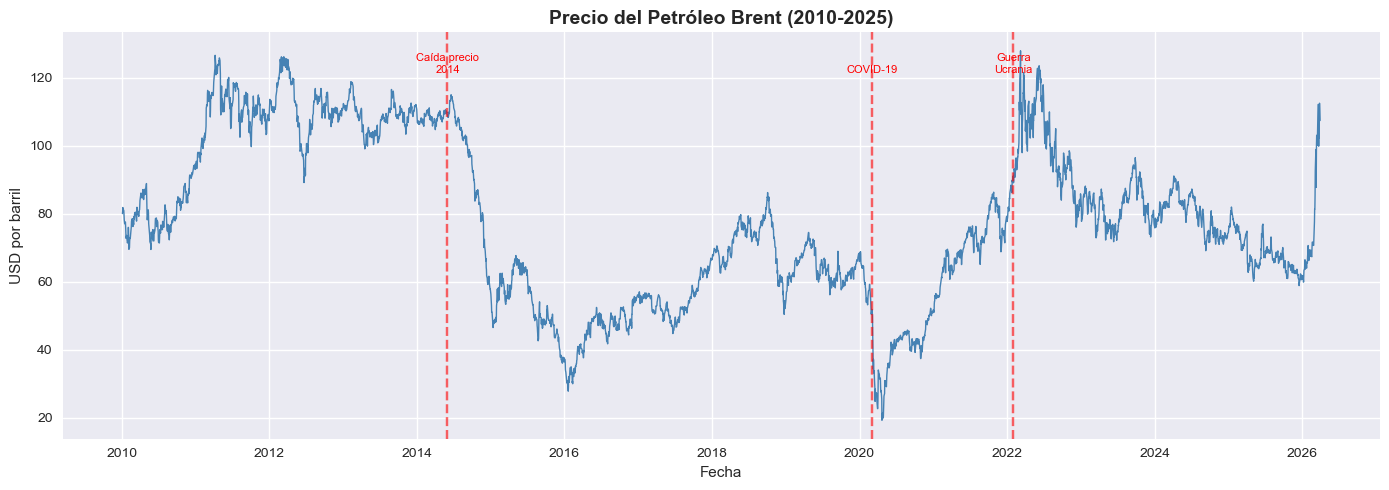

Gráfico guardado en outputs/


In [7]:
# Graficar la serie del Brent
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(brent.index, brent["precio_brent"], color="steelblue", linewidth=1)

ax.set_title("Precio del Petróleo Brent (2010-2025)", fontsize=14, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("USD por barril")

# Marcar eventos clave
eventos = {
    "2014-06": "Caída precio\n2014",
    "2020-03": "COVID-19",
    "2022-02": "Guerra\nUcrania"
}

for fecha, label in eventos.items():
    ax.axvline(pd.Timestamp(fecha), color="red", linestyle="--", alpha=0.6)
    ax.text(pd.Timestamp(fecha), brent["precio_brent"].max() * 0.95,
            label, fontsize=8, color="red", ha="center")

plt.tight_layout()
plt.savefig("../outputs/01_serie_brent.png", dpi=150)
plt.show()

print("Gráfico guardado en outputs/")